## Student Performance Indicator


### Life Cycle of Machine Learning Project

- Understanding The Problem Statement 
- Data Collection 
- Data Checks To Perform 
- Exploratory Data Analysis
- Data Pre-Processing
- Model Training
- Chossing Best Model

1) ### Problem Statement

- This Project Understands How The Student's Performance (Test Score) is Affected by Other Variables Such as Gender,Ethenicity, Parental Level of Education, Lunch and Test Preperation Course.

2) ### Data Collection

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The Data Consists of 8 Columns and 1000 Rows.

### Importing Data And Required Packages

Import pandas, numpys, matplotlib, seaborn, warnings Librarys.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
## Importing the Csv Data using Pandas as DataFrame

df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

### Data Set Information:

- Gender: M or F
- race/ethincity:ethincity of Student --> (Groups A,B,C,D,E)
- Parent Level Of Education: parents Final Education --> (bachlore degree,some college,Master Degree,associate degree high school)
- lunch : Having a Lunch Before Test(Standard or free/Reduced)
- test preperation course: Complete or not complete before test
- math Score
- reading Score
- Writing Score

3) ### Data Checks to Perform

- check missing values.
- check Duplicate value.
- check Datatype.
- check the number of unique values in the column.
- check Statistic or Dataset.
- check various categories present in the different categorical Columns.


In [8]:
## Checking Missing Values.
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

- There is No Missing values in the Dataset 

In [ ]:
'''-----------------------------------------------> Checking the Duplicates <--------------------------------------'''
df.duplicated().sum()

0

- There is No duplicate dvalues in Dataset

In [ ]:
'''------------------------------------------------> checking the Datatype <---------------------------------------------'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
'''-----------------------------------------------------> checking the number of Unique Values in the Columns <----------------------------------------------'''
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [12]:
'''--------------------------------------------------> Checking the Static of Data set <-----------------------------------------------'''
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


insights

- from abouve discription the numerical data of all mean is very close to each other in between 66 to 68.
- All Standard Deveations are also Close - 14.6 to 15.1.
- while there is a minimum score 0 for math,for writing minimum is much higher = 10 and for reading myet higher =17.

### Exploring Data

In [14]:
print("Categories in 'gender' variable: ",end='')
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ",end='')
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' variable: ",end='')
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ",end='')
print(df['lunch'].unique())

print("Categories in 'test_preparation_course' variable: ",end='')
print(df['test_preparation_course'].unique())


Categories in 'gender' variable: ['female' 'male']
Categories in 'race_ethnicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable: ['none' 'completed']


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [17]:
### Defining Numerical and Categorical Columns
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} Numerical Feature: {}'.format(len(numerical_features),numerical_features))
print('We have {} Categorical Feature: {}'.format(len(categorical_features),categorical_features))

We have 3 Numerical Feature: ['math_score', 'reading_score', 'writing_score']
We have 5 Categorical Feature: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### Adding columns for "Total Score" and "Average". in a Dataset

In [18]:
df['Total Score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['Average'] = df['Total Score'] // 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72
1,female,group C,some college,standard,completed,69,90,88,247,82
2,female,group B,master's degree,standard,none,90,95,93,278,92
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49
4,male,group C,some college,standard,none,76,78,75,229,76


In [19]:
reading_full = df[df['reading_score'] == 100]['Average'].count()
writing_full = df[df['writing_score'] == 100]['Average'].count()
math_full = df[df['math_score'] == 100]['Average'].count()

print(f' Number of Students With Full Marks in Maths: {math_full}')
print(f' Number of Students with Full Marks in Writting: {writing_full}')
print(f' Number of Students with Full Marks in Reading {reading_full}')

 Number of Students With Full Marks in Maths: 7
 Number of Students with Full Marks in Writting: 14
 Number of Students with Full Marks in Reading 17


In [20]:
reading_less_20 = df[df['reading_score'] <= 20]['Average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['Average'].count()
math_less_20 = df[df['math_score'] <= 20]['Average'].count()

print(f' Number of Students With less than 20 Marks in Maths: {math_less_20}')
print(f' Number of Students With less than 20 Marks in Reading: {reading_less_20}')
print(f' Number of Students With less than 20 Marks in Writing: {writing_less_20}')

 Number of Students With less than 20 Marks in Maths: 4
 Number of Students With less than 20 Marks in Reading: 1
 Number of Students With less than 20 Marks in Writing: 3


### Note: 
- From Above We got both Good And Worst Performances

## 4). Exploring Data Visualization


### Visualizing average score distibution to make Some Conclusion

- Histogram
- Kernel Distibution Function(KDE)

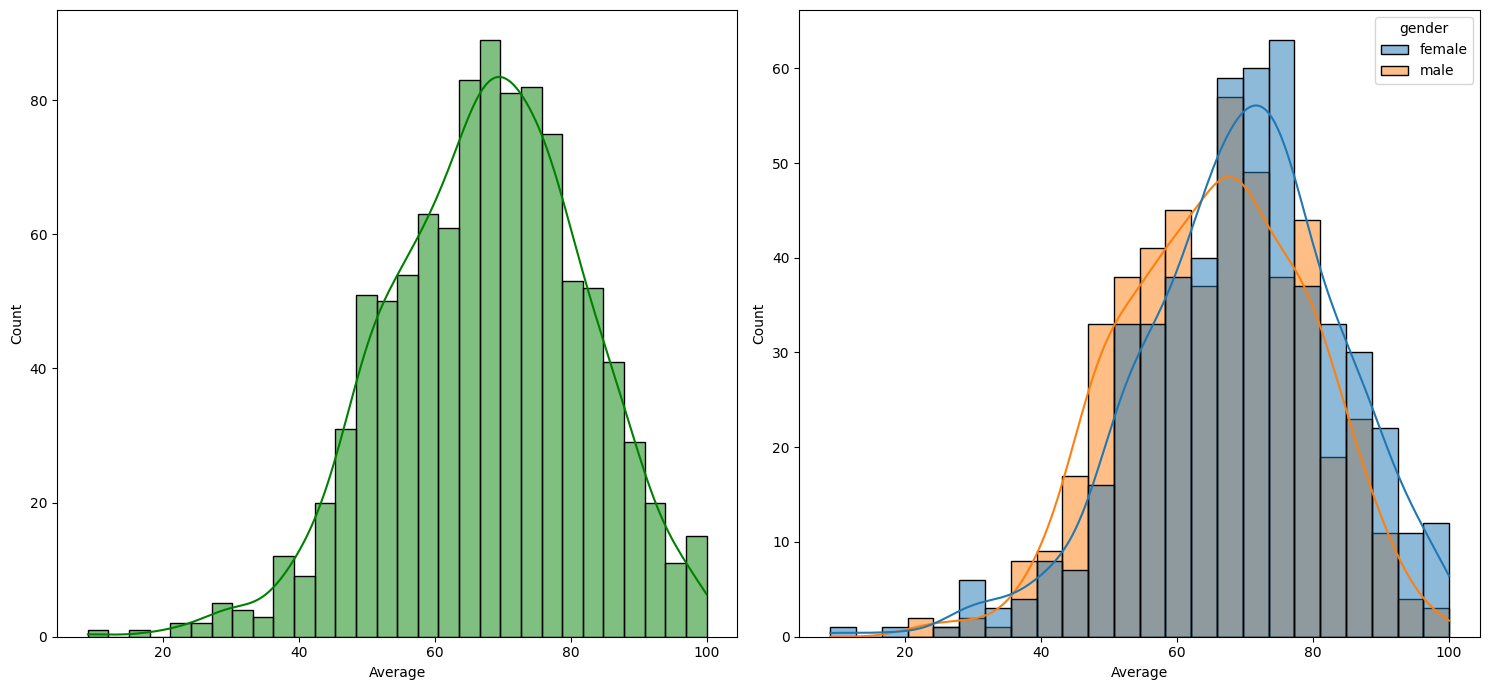

In [24]:
'''---------------------------------------------------> Histogram and KDE <----------------------------------------------'''
fig , axs = plt.subplots(1, 2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',kde=True,hue='gender')
plt.tight_layout()
plt.show()


- Female Students Tend to Perform Wll than Male Students

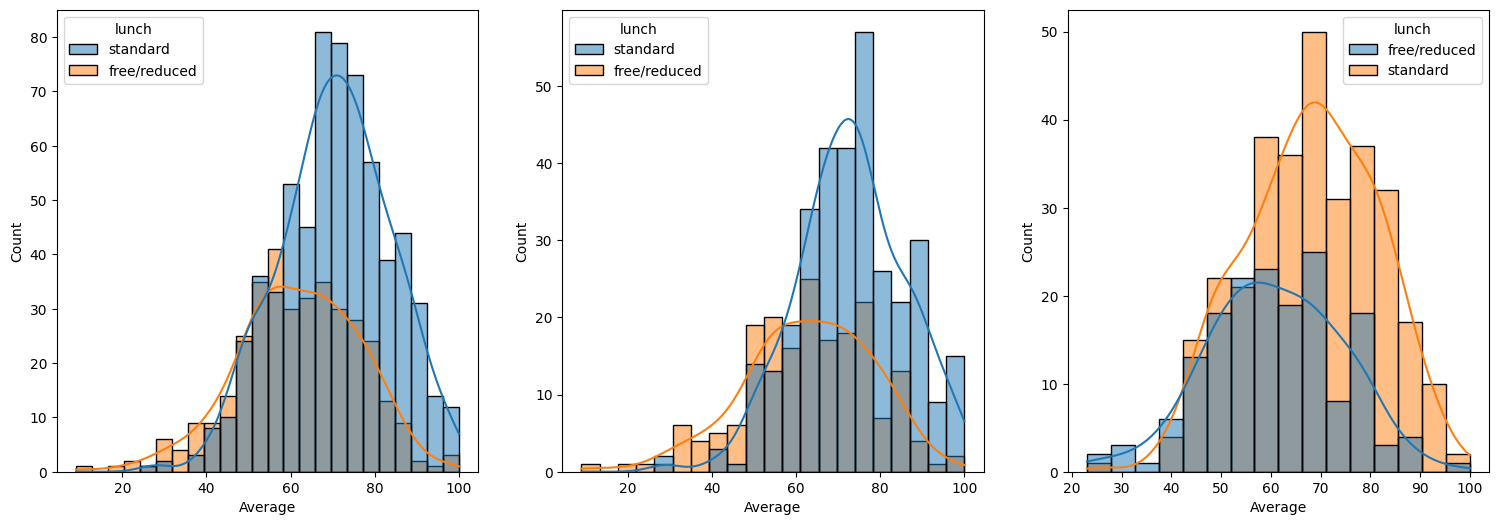

In [ ]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'],x='Average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'],x='Average',kde=True,hue='lunch')
plt.show()

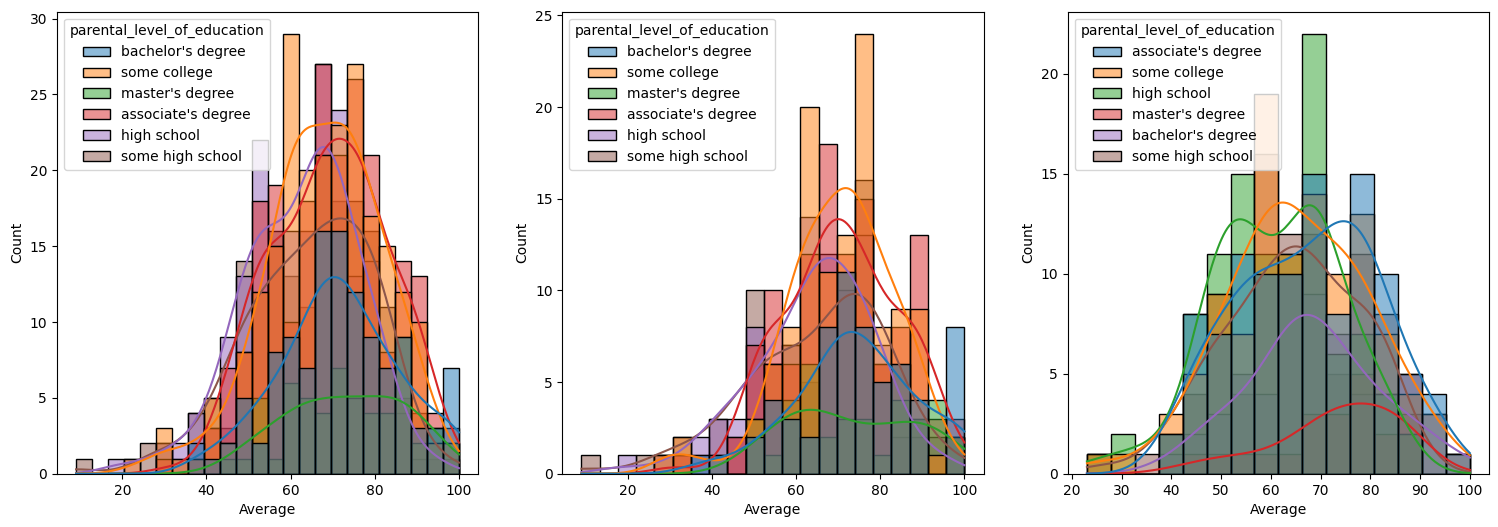

In [28]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'],x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'],x='Average',kde=True,hue='parental_level_of_education')
plt.show()

<Axes: xlabel='Average', ylabel='Count'>

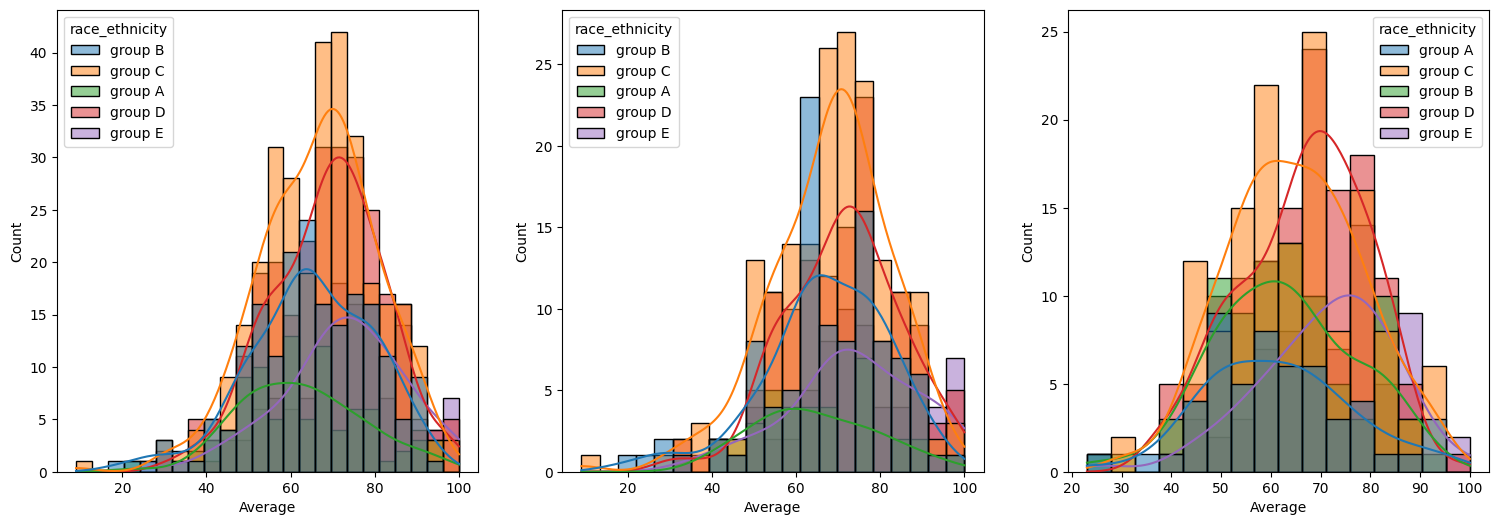

In [29]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='race_ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'],x='Average',kde=True,hue='race_ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'],x='Average',kde=True,hue='race_ethnicity')

### Maximum Score of Students in three Subjects


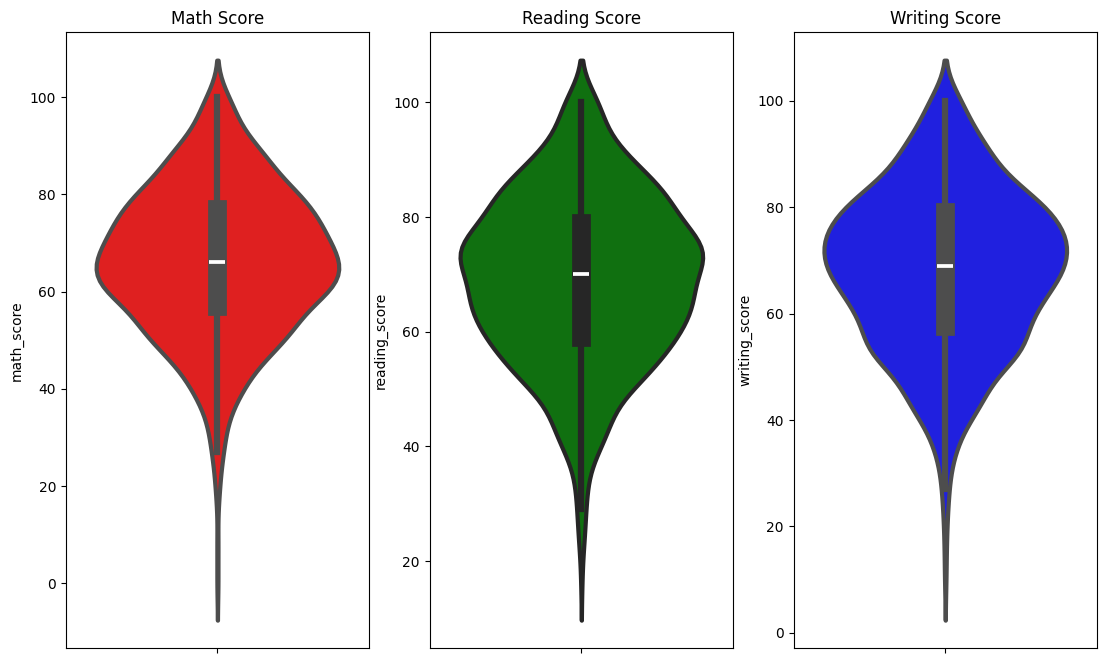

In [30]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Math Score')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title('Reading Score')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1,4,3)
plt.title('Writing Score')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
 8   Total Score                  1000 non-null   int64 
 9   Average                      1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.2+ KB


### Multivariate Analysis using pieplot

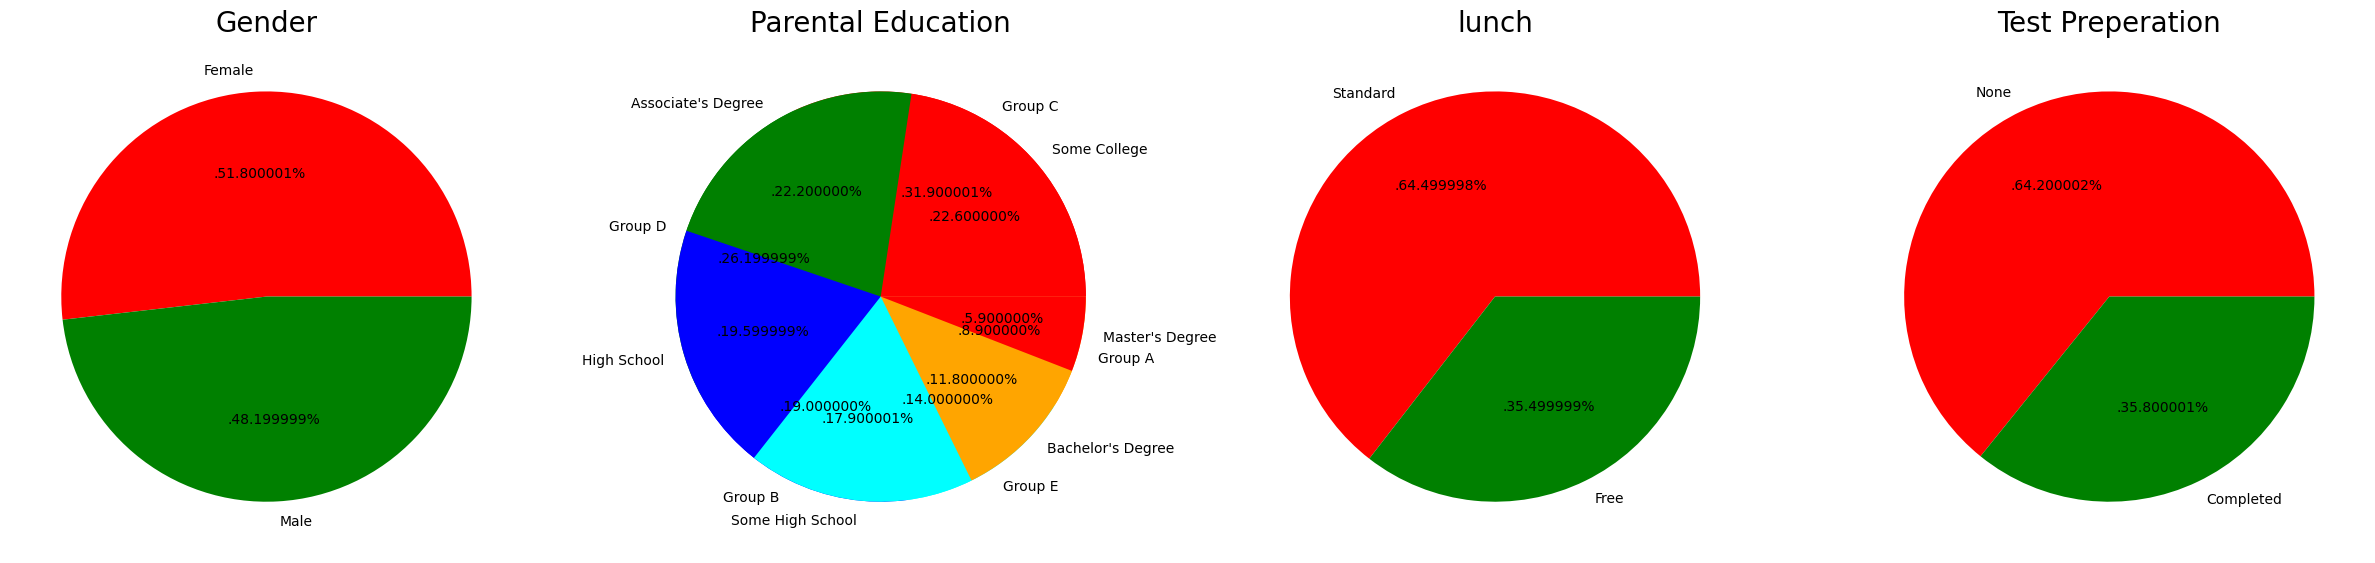

In [36]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['red','green']

plt.pie(size,colors= color,labels=labels,autopct= '.%2f%%')
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C','Group D','Group B','Group E','Group A'
color = ['red','green','blue','cyan','orange']

plt.pie(size,colors= color,labels=labels,autopct= '.%2f%%')
plt.title('race_ethnicity',fontsize=20)
plt.axis('off')


plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = 'Standard','Free'
color = ['red','green']

plt.pie(size,colors= color,labels=labels,autopct= '.%2f%%')
plt.title('lunch',fontsize=20)
plt.axis('off')


plt.subplot(1,5,4)
size = df['test_preparation_course'].value_counts()
labels = 'None','Completed'
color = ['red','green']

plt.pie(size,colors= color,labels=labels,autopct= '.%2f%%')
plt.title('Test Preperation',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College',"Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red','green','blue','cyan','orange']

plt.pie(size,colors= color,labels=labels,autopct= '.%2f%%')
plt.title('Parental Education',fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

### Univarate Analysis(How is Distibution of GFender ? )

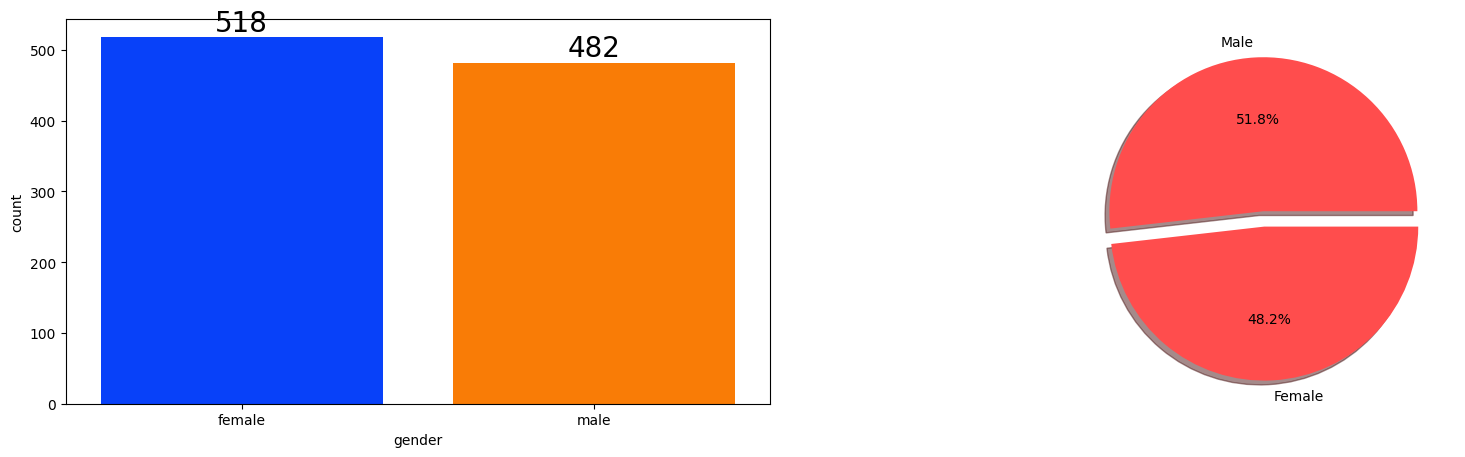

In [38]:
f,ax = plt.subplots(1,2,figsize=(20,5))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d'])
plt.show()

### Bivariate Analysis (is gender as any imapct on student Performance ?)

In [40]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,Total Score,Average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.239382
male,68.728216,65.473029,63.311203,197.512448,65.516598


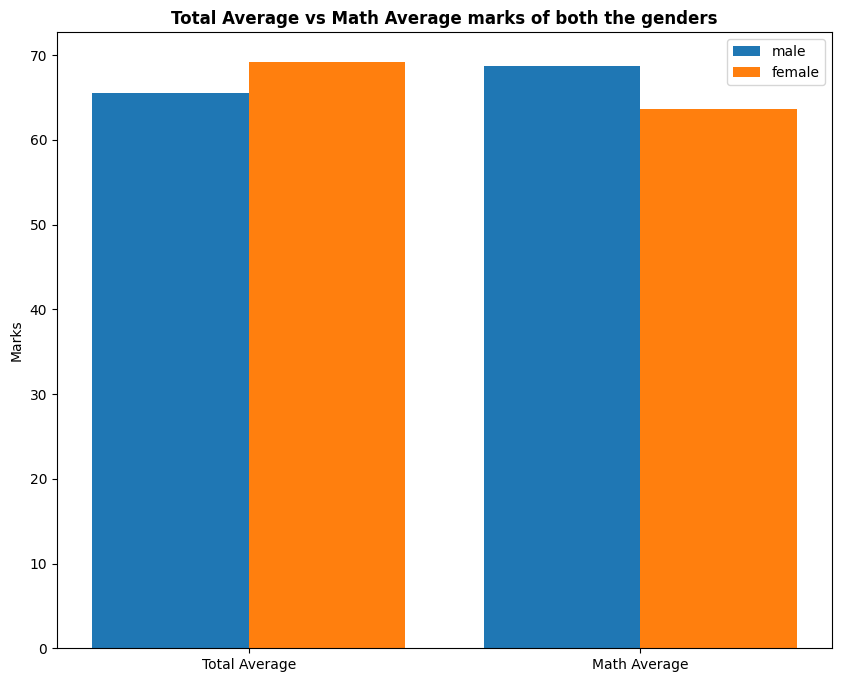

In [41]:
plt.figure(figsize=(10,8))
X = ['Total Average','Math Average']

female_score = [gender_group['Average'][0],gender_group['math_score'][0]]
male_score = [gender_group['Average'][1],gender_group['math_score'][1]]

x_asix = np.arange(len(X))

plt.bar(x_asix - 0.2,male_score,0.4,label='male')
plt.bar(x_asix + 0.2,female_score,0.4,label='female')

plt.xticks(x_asix,X)
plt.ylabel("Marks")
plt.title("Total Average vs Math Average marks of both the genders",fontweight='bold')
plt.legend()
plt.show()


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
 8   Total Score                  1000 non-null   int64 
 9   Average                      1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.2+ KB


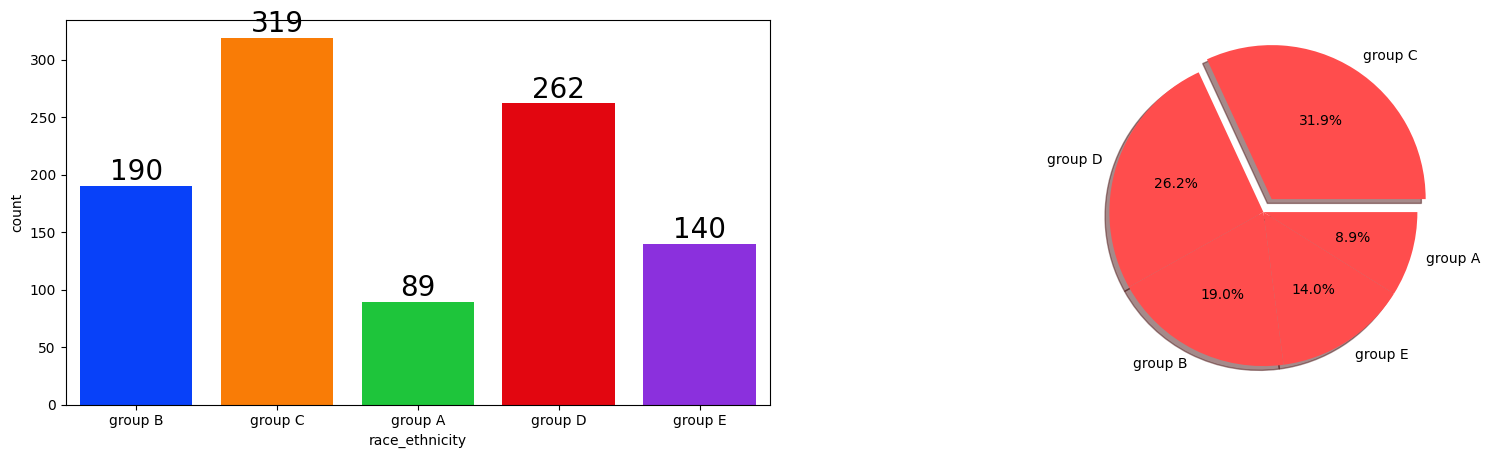

In [44]:
f,ax = plt.subplots(1,2,figsize=(20,5))
sns.countplot(x=df['race_ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.pie(x=df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d'])
plt.show()

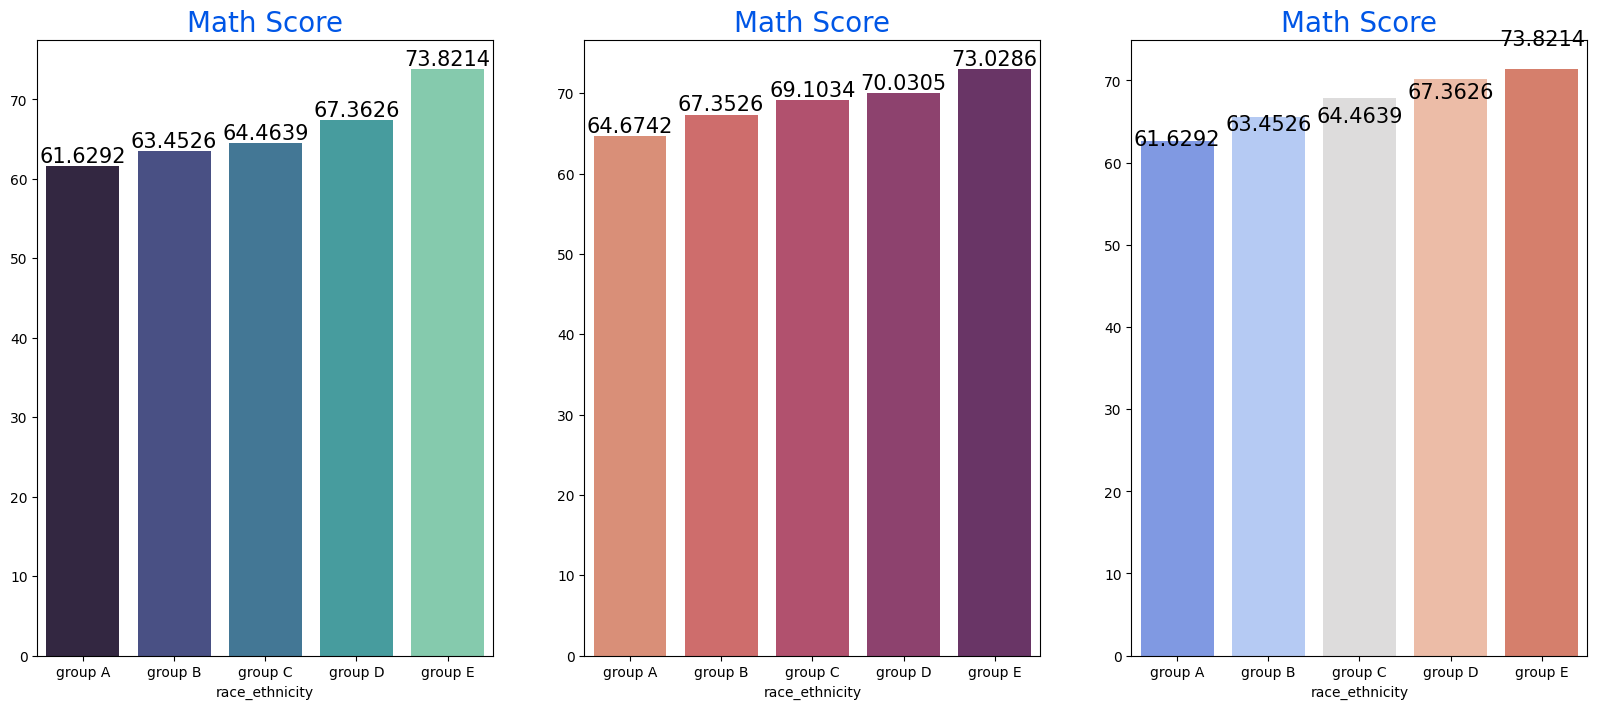

In [48]:
group_data2 = df.groupby('race_ethnicity').mean(numeric_only=True)
f,ax = plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=group_data2['math_score'].index,y=group_data2['math_score'].values,palette='mako',ax=ax[0])
ax[0].set_title('Math Score',color='#0056e6',size=20)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=group_data2['reading_score'].index,y=group_data2['reading_score'].values,palette='flare',ax=ax[1])
ax[1].set_title('Math Score',color='#0056e6',size=20)
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=group_data2['writing_score'].index,y=group_data2['writing_score'].values,palette='coolwarm',ax=ax[2])
ax[2].set_title('Math Score',color='#0056e6',size=20)
for container in ax[0].containers:
    ax[2].bar_label(container,color='black',size=15)

# plt.pie(x=df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d'])
# plt.show()

### Parental Level of Education background

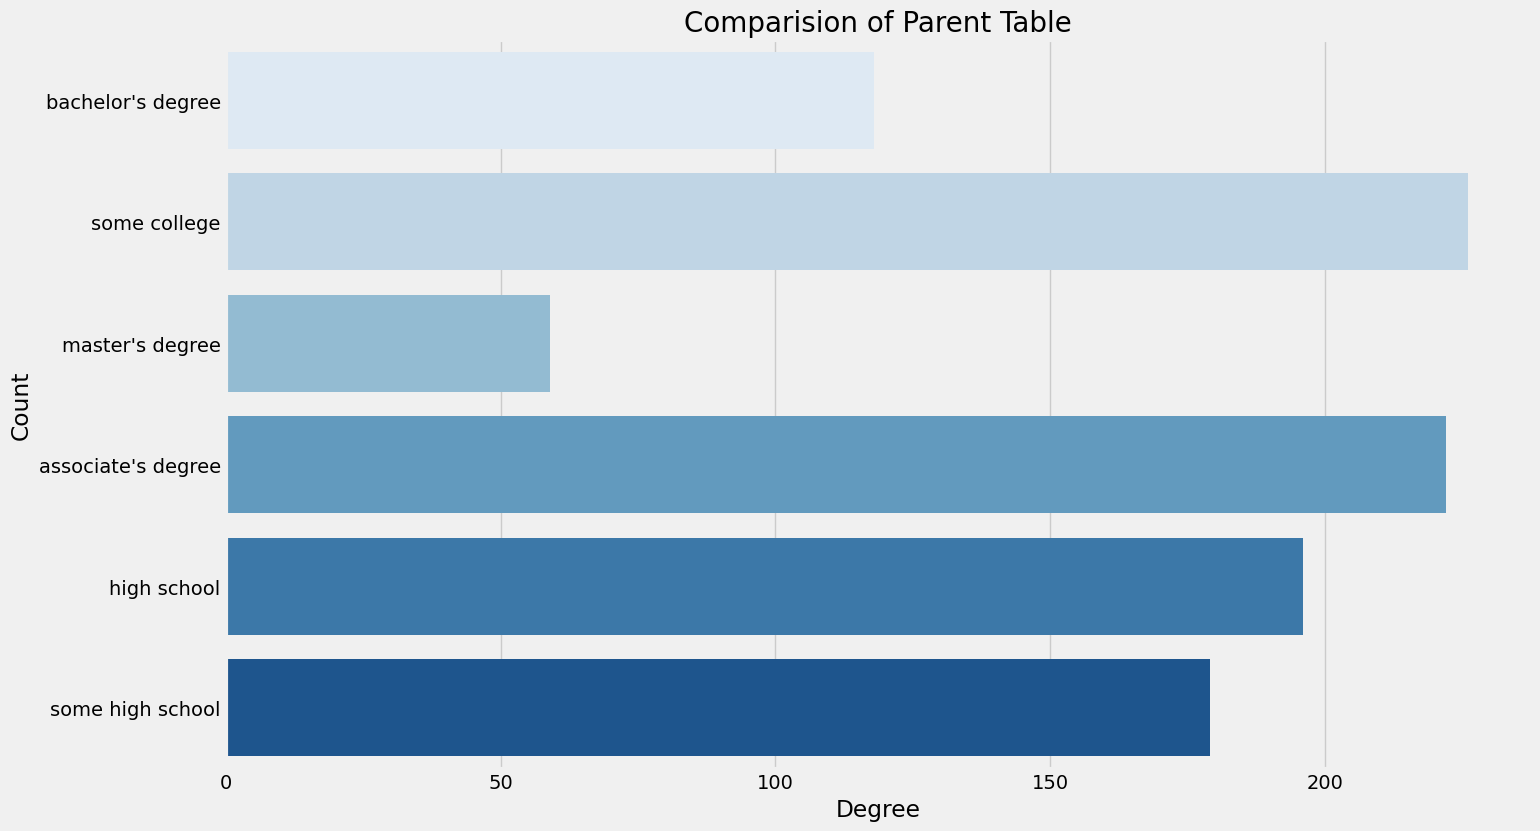

In [50]:
plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'],palette='Blues')
plt.title('Comparision of Parent Table',fontweight=30,fontsize=20)
plt.xlabel('Degree')
plt.ylabel('Count')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


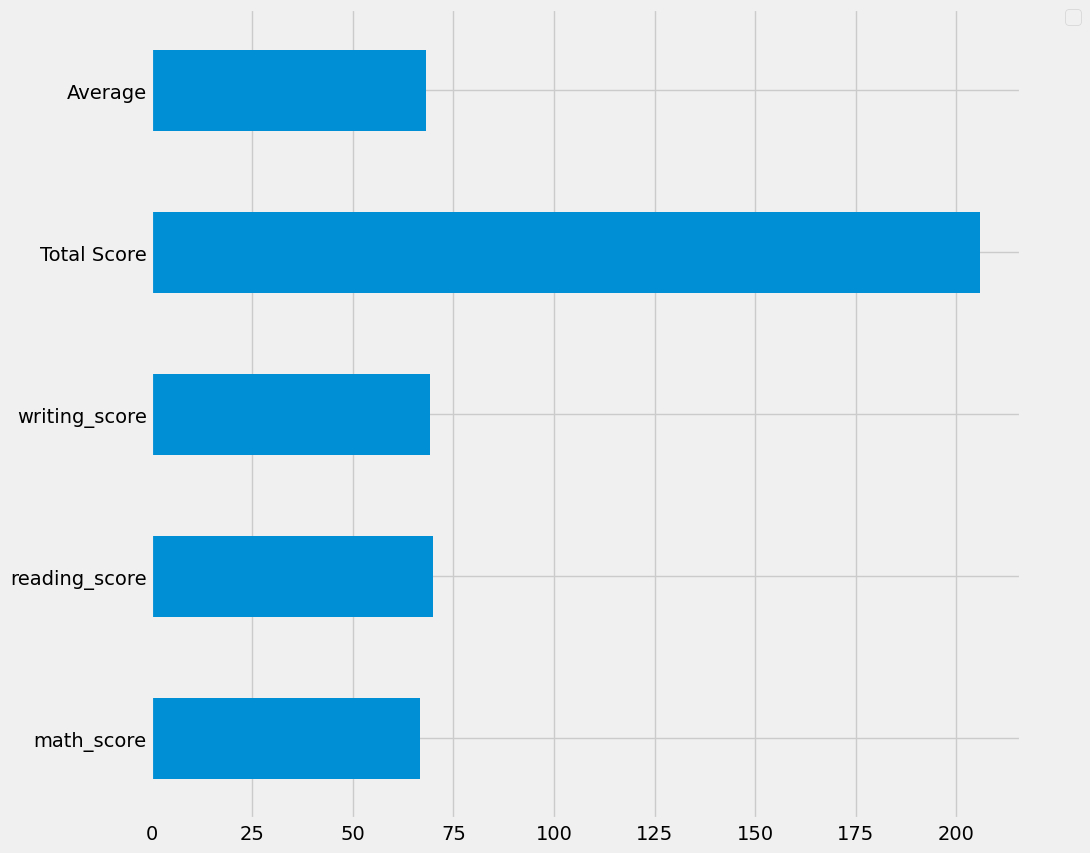

In [52]:
df.groupby('parental_level_of_education').mean(numeric_only=True).agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05,1),loc=2, borderaxespad=0.)
plt.show()

### Univariate Analysis

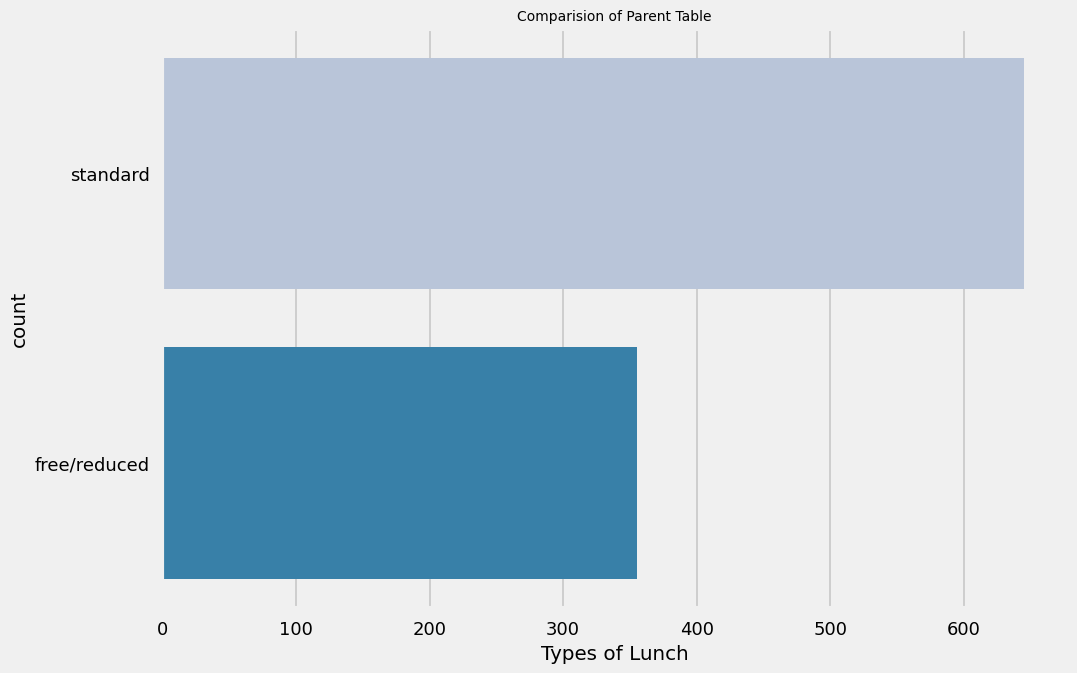

In [56]:
plt.rcParams['figure.figsize'] = (8,5)
plt.style.use('seaborn-talk')
sns.countplot(df['lunch'],palette='PuBu')
plt.title('Comparision of Parent Table',fontweight=15,fontsize=10)
plt.xlabel('Types of Lunch')
plt.ylabel('count')
plt.show()

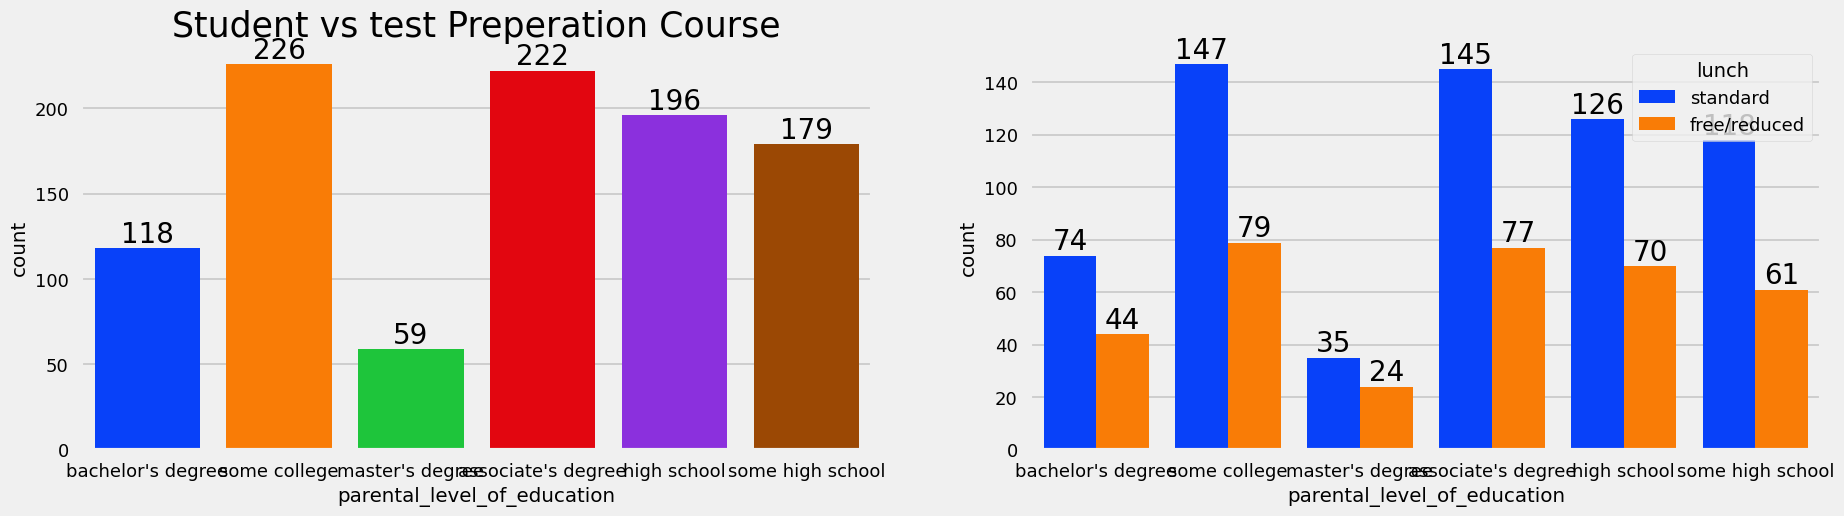

In [57]:
f,ax = plt.subplots(1,2,figsize=(20,5))
sns.countplot(x=df['parental_level_of_education'],data=df,palette='bright',hue='parental_level_of_education',saturation=0.95,ax=ax[0])
ax[0].set_title('Student vs test Preperation Course',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

sns.countplot(x=df['parental_level_of_education'],data=df,palette='bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)


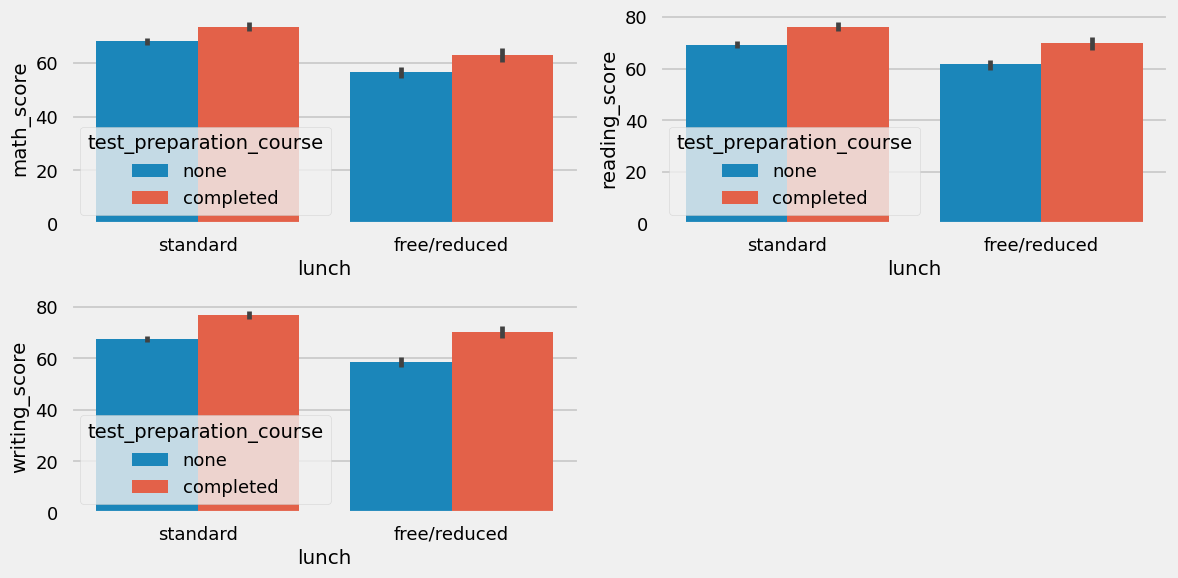

In [60]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot(x=df['lunch'],y=df['math_score'],hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot(x=df['lunch'],y=df['reading_score'],hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot(x=df['lunch'],y=df['writing_score'],hue=df['test_preparation_course'])

plt.tight_layout()
plt.show()


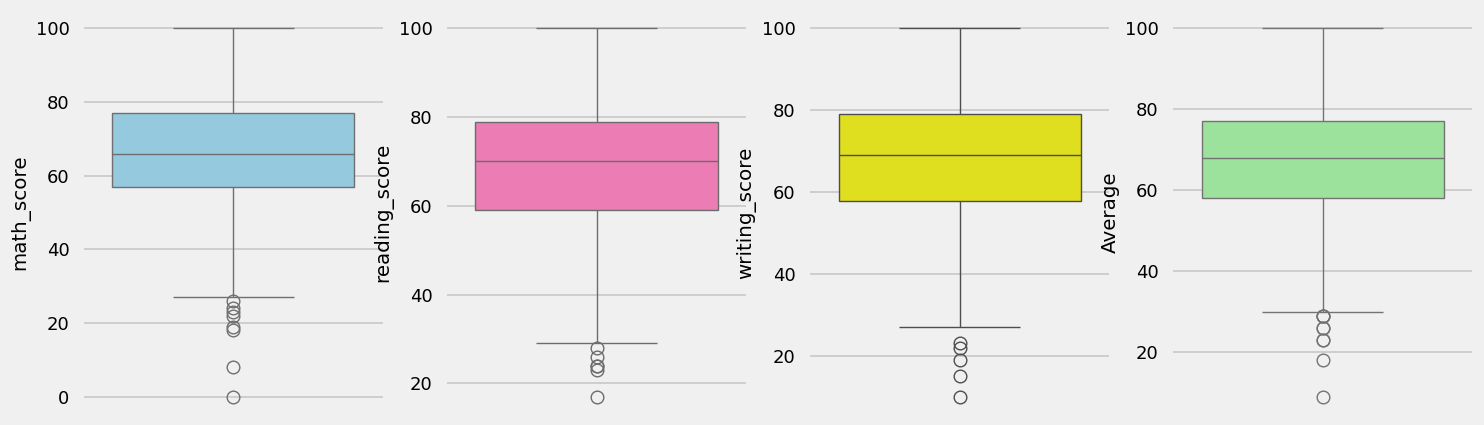

In [61]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average'],color='lightgreen')
plt.show()


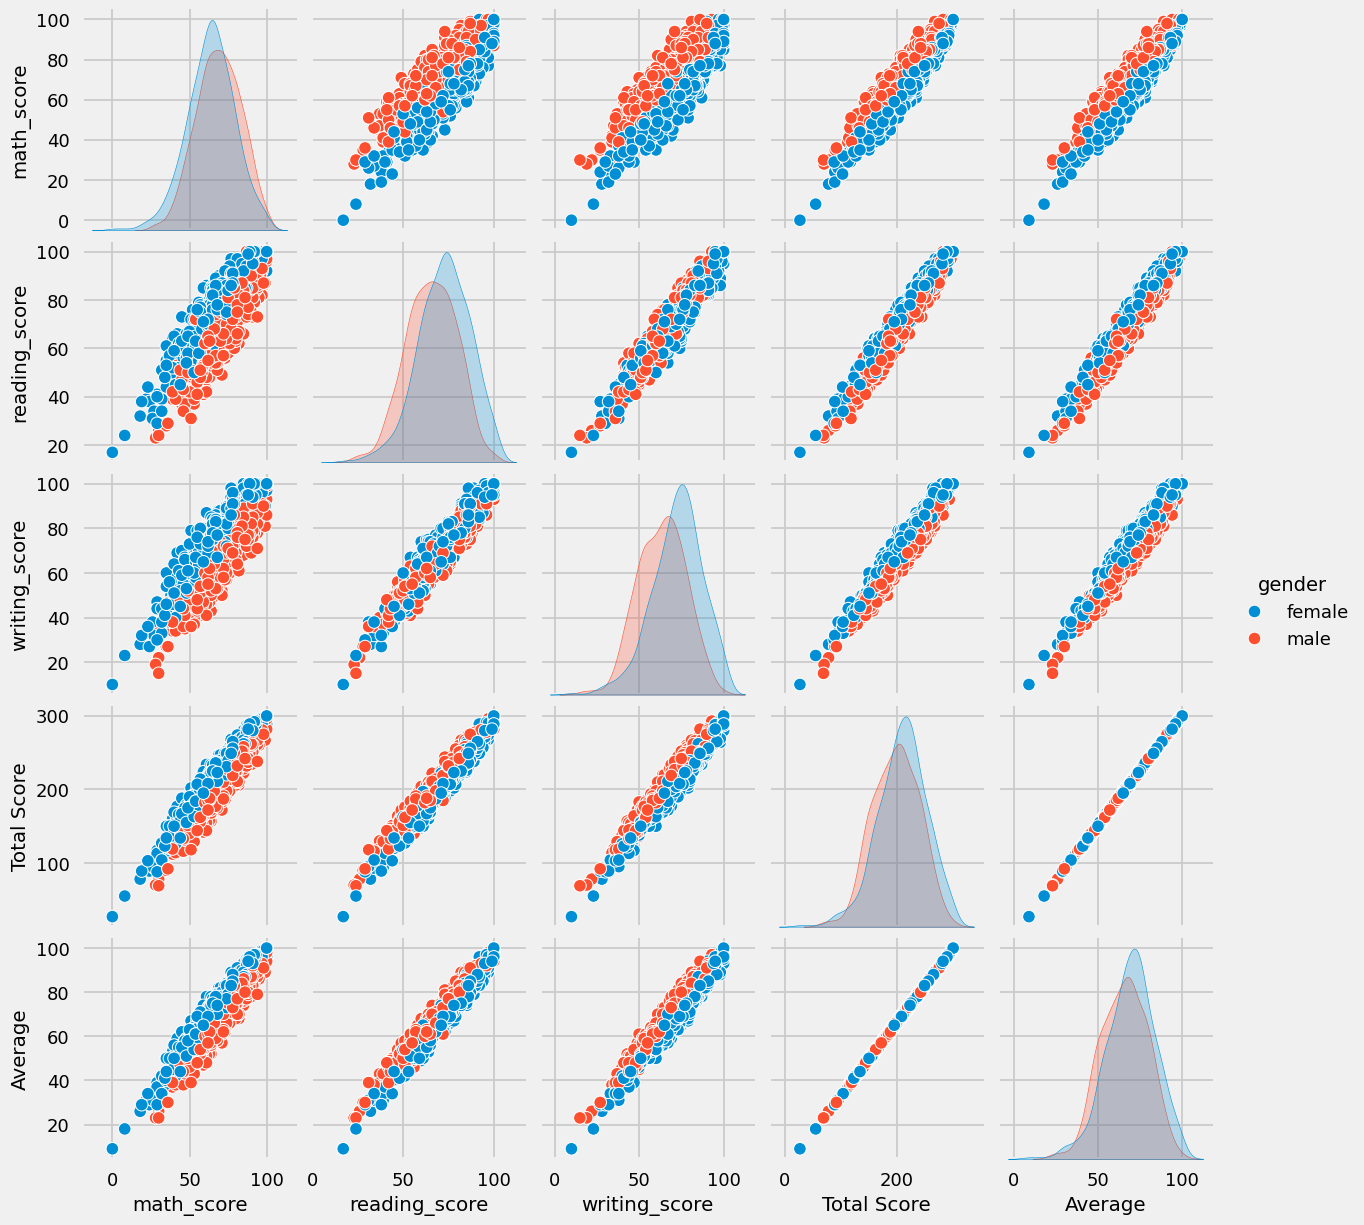

In [62]:
sns.pairplot(df,hue='gender')
plt.show()

## Conclusion:

- Student's Performance is releated with lunch,race,parental level Education.
- Femeals lead in Pass Percentage.
- Students Performance is not mUch releated with Test preperation Course.
- Finishing preperation course is Benefital.